## Parsing data from text file result

In [1]:
# app, source class, source function, sink class, sink function, communication method
import re

STMT_PATTERN = re.compile(
    r"stmt:\s*<([\w\.]+):\s+[\w\<\>\.\s]+\s+([\w\<\>]+)(?:\(|>)"
)

comms = {"gp_bl.txt": "bluetooth", "gp_gen.txt": "wi-fi", "gp_local.txt": "local"}

def parse_sources_and_sink(flow_str):
    sources_part, sink_part = flow_str.split("------->")

    # Extract sources
    sources = STMT_PATTERN.findall(sources_part)
    source_pairs = [(cls, method) for cls, method in sources]

    # Extract sink
    sink_match = STMT_PATTERN.search(sink_part)
    sink_pair = (sink_match.group(1), sink_match.group(2)) if sink_match else None

    return source_pairs, sink_pair

In [ ]:
parsed_output = []
file_name = 'gp_bl_1.txt'
with open(file_name, 'r') as file:
    prev_line = ""
    for line in file:
        if line.startswith("The flow was found from:") and prev_line:
            # previous line is the app name
            app_name = prev_line
        prev_line = line.strip()

        if "------->" in line:
            sources, sink = parse_sources_and_sink(line)
            for source in sources:
                parsed_output.append([app_name, source[0], source[1], sink[0], sink[1], comms[file_name]])

In [ ]:
import csv
with open('flowanalysis-parsed-output.csv', 'a', newline='') as csvfile:
    writer = csv.writer(csvfile)
    # writer.writerow(["app", "source_class", "source_function", "sink_class", "sink_function", "communication_method"])
    writer.writerows(parsed_output)

In [8]:
## bluetooth
# app, source class, source function, sink class, sink function, communication method
import re

BLUETOOTH_STMT_PATTERN = re.compile(
r"stmt:\s*(?:[^:]+:\s+)?(?:<)?([\w\.]+):\s+[\w\.\<\>\[\]\$]+\s+([\w\<\>\$]+\(?[^\(\)>]*\)?)(?:>|,|\))")

comms = {"gp_bl_1.txt": "bluetooth", "gp_bl_2.txt": "bluetooth", "gp_gen.txt": "wi-fi", "gp_local_1.txt": "local", "gp_local_2.txt": "local"}

def parse_sources_and_sink(flow_str):
    # Split the line into the Source list and the Sink
    parts = flow_str.split("------->")
    if len(parts) < 2: return [], None
    
    sources_part, sink_part = parts[0], parts[1]

    # 1. Extract ALL sources (handles the list [ICC, ICC, ICC])
    source_pairs = BLUETOOTH_STMT_PATTERN.findall(sources_part)

    # 2. Extract the sink (handles the complex signature)
    sink_match = BLUETOOTH_STMT_PATTERN.search(sink_part)
    sink_pair = (sink_match.group(1), sink_match.group(2)) if sink_match else ("Unknown", "Unknown")

    return source_pairs, sink_pair

parsed_output = []
file_name = 'gp_local_2.txt'

with open(file_name, 'r') as file:
    app_name = "Unknown"
    prev_line = ""
    for line in file:
        line = line.strip()
        if not line: continue
        
        # Improved App Name detection: 
        # If the previous line was a divider, this line is the app name
        if prev_line.startswith("---------"):
            app_name = line
            
        if "------->" in line:
            sources, sink = parse_sources_and_sink(line)
            for source in sources:
                # This now captures: [app, class, method(args), sink_class, sink_method, comm]
                parsed_output.append([app_name, source[0], source[1], sink[0], sink[1], comms[file_name]])
        
        prev_line = line

with open('flowanalysis-parsed-output.csv', 'a', newline='') as csvfile:
    writer = csv.writer(csvfile)
    # writer.writerow(["app", "source_class", "source_function", "sink_class", "sink_function", "communication_method"])
    writer.writerows(parsed_output)

In [ ]:
for key in filtered_output_dict_count:
    print(f"{key} & {round(output_dict_count[key][0]/total_dict[key]*100,2)} & {round(filtered_output_dict_count[key][1]/filtered_total_dict[key]*100,2)} \\\ \hline")

Productivity & 51.89 & 99.24 \\ \hline
Communication & 46.86 & 98.88 \\ \hline
Health & Fitness & 62.69 & 99.71 \\ \hline
Lifestyle & 52.4 & 99.59 \\ \hline
Tools & 49.45 & 98.95 \\ \hline
Business & 59.82 & 99.2 \\ \hline
House & Home & 57.37 & 99.49 \\ \hline
Auto & Vehicles & 54.19 & 99.21 \\ \hline
Music & Audio & 42.47 & 99.12 \\ \hline
Entertainment & 42.28 & 99.26 \\ \hline
Video Players & Editors & 47.65 & 99.48 \\ \hline
Weather & 48.48 & 98.17 \\ \hline
Photography & 46.98 & 98.4 \\ \hline
Education & 49.57 & 99.13 \\ \hline


## Plotting the flowanalysis data

In [13]:
import csv 

permissions = []
# Open the file in read mode, specifying newline=''
with open("flowanalysis-parsed-output.csv", mode='r', newline='', encoding='utf-8') as file:
    # Create a reader object
    reader = csv.reader(file)
    for row in reader:
        permissions.append(row[2])

permissions = list(set(permissions))

# permissions = list(set(permissions))

In [12]:
permissions

['getInputStream()',
 'queryBroadcastReceivers',
 'queryIntentServices',
 'getSSID',
 'getInstalledPackages',
 'execute()',
 'getAddress',
 'queryContentProviders',
 'getCid',
 'getCharacteristics()',
 'getDeviceId',
 'getMacAddress',
 'getSimSerialNumber',
 'queryIntentActivities',
 'getCharacteristic(java.util.UUID)',
 'source_function',
 'getTimeZone',
 'getLatitude',
 'getInstalledApplications',
 'getLine1Number',
 'getSubscriberId',
 'getLac',
 'read',
 'getCountry',
 'getLongitude',
 'getLastKnownLocation']

In [14]:
sensitivity_order = ['getSubscriberId',
'getDeviceId',
'getSimSerialNumber',
'getLine1Number',
'getLastKnownLocation',
'getLatitude',
'getLongitude',
'getAddress',
'getMacAddress',
'getSSID',
'getInstalledApplications', ##
'getInstalledPackages',
'queryIntentActivities',
'queryIntentServices',
'queryContentProviders',
'queryBroadcastReceivers',
'getCountry',
'getTimeZone',
'getCid', ##
'getLac',
'getInputStream()', ##
'read',
'execute()',
'getCharacteristics()',
'getCharacteristic(java.util.UUID)',
'source_function',
]

In [15]:
source_color_map = {
    'getSubscriberId': '#d7191c', 
    'getDeviceId': '#d7191c', 
    'getSimSerialNumber': '#d7191c', 
    'getLine1Number': '#d7191c', 
    'getLastKnownLocation': '#d7191c', 
    'getLatitude': '#d7191c', 
    'getLongitude': '#d7191c', 
    'getAddress': '#d7191c', 
    'getMacAddress': '#d7191c', 
    'getSSID': '#d7191c', 
    'getInstalledApplications': '#fdae61', ##
    'getInstalledPackages': '#fdae61',
    'queryIntentActivities': '#fdae61',
    'queryIntentServices': '#fdae61',
    'queryContentProviders': '#fdae61',
    'queryBroadcastReceivers': '#fdae61',
    'getCountry': '#fdae61',
    'getTimeZone': '#fdae61',
    'getCid': '#1a9641',  ##
    'getLac': '#1a9641', 
    'getInputStream()': '#2b83ba',  ##
    'read': '#2b83ba', 
    'execute()': '#2b83ba', 
    'getCharacteristics()': '#2b83ba', 
    'getCharacteristic(java.util.UUID)': '#2b83ba', 
    'source_function':'#2b83ba', 
}

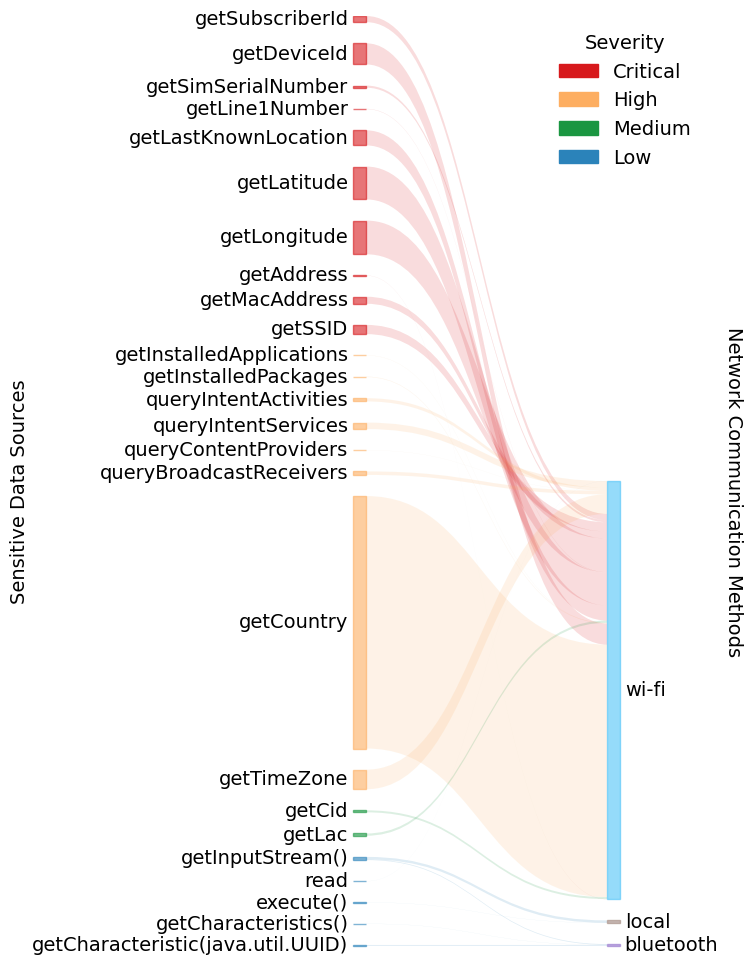

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
import matplotlib.colors as mcolors
import matplotlib
# import io

# 1. Load the data
df = pd.read_csv("flowanalysis-parsed-output.csv")

# 2. Process data for the Sankey flow
counts = df.groupby(['source_function', 'communication_method']).size().reset_index(name='value')

# 3. Define the custom sensitivity order
# sensitivity_order = permissions 
# source_color_map = {
#     'getSimSerialNumber': '#d7191c',  # Red (Highest)
#     'getMacAddress': '#fdae61',       # Orange
#     'getDeviceId': '#fee08b',         # Yellow
#     'getCountry': '#a6d96a',          # Light Green
#     'getTimeZone': '#1a9641',         # Green
#     'queryIntentActivities': '#2b83ba' # Blue (Lowest)
# }
sink_color_map = {
    'wi-fi': '#4fc3f7',      # Light Blue
    'bluetooth': '#9575cd',  # Purple
    'local': '#a1887f'       # Brown
}

severity_colors = {
    'critical': '#d7191c',
    'high': '#fdae61',
    'medium': '#1a9641',
    'low': '#2b83ba'
}

# Sort labels based on the order
sources = sorted(counts['source_function'].unique(), 
                 key=lambda x: sensitivity_order.index(x) if x in sensitivity_order else 99)
sources = sources[::-1]
sinks = sorted(counts['communication_method'].unique())

def draw_sankey(df, sources, sinks, output_file):
    # fig, ax = plt.subplots(figsize=(10, 7))
    font = {#'family' : 'normal',
        'size'   : 14}
    matplotlib.rc('font', **font)

    # fig, (ax_cb, ax) = plt.subplots(1, 2, figsize=(7, 10), gridspec_kw={'width_ratios': [1, 25]})
    fig, ax = plt.subplots(figsize=(7, 10))

    total_weight = df['value'].sum()
    gap = 0.05 * total_weight
    
    # Calculate Heights
    source_heights = {s: df[df['source_function'] == s]['value'].sum() for s in sources}
    sink_heights = {si: df[df['communication_method'] == si]['value'].sum() for si in sinks}
    
    # Draw Source Nodes
    curr_y, source_pos = 0, {}
    for s in sources:
        h = source_heights[s]
        color = source_color_map.get(s, 'gray')
        ax.add_patch(patches.Rectangle((0, curr_y), 0.05, h, color=color, alpha=0.6))
        ax.text(-0.02, curr_y + h/2, s, ha='right', va='center')
        source_pos[s] = curr_y
        curr_y += h + gap
        
    # Draw Sink Nodes
    curr_y, sink_pos = 0, {}
    for si in sinks:
        h = sink_heights[si]
        ax.add_patch(patches.Rectangle((1, curr_y), 0.05, h, color=sink_color_map.get(si, '#DDDDDD'), alpha=0.6)) ##change the color of sink
        ax.text(1.07, curr_y + h/2, si, ha='left', va='center')
        sink_pos[si] = curr_y
        curr_y += h + gap
        
    # Draw Flows
    s_off = {s: 0 for s in sources}
    si_off = {si: 0 for si in sinks}
    for _, row in df.iterrows():
        s, si, val = row['source_function'], row['communication_method'], row['value']
        color = source_color_map.get(s, 'gray')
        ys, ye = source_pos[s] + s_off[s], sink_pos[si] + si_off[si]
        
        verts = [(0.05, ys), (0.5, ys), (0.5, ye), (1.0, ye), 
                 (1.0, ye + val), (0.5, ye + val), (0.5, ys + val), (0.05, ys + val), (0.05, ys)]
        codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, 
                 Path.LINETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CLOSEPOLY]
        ax.add_patch(patches.PathPatch(Path(verts, codes), facecolor=color, alpha=0.15, lw=0))
        s_off[s] += val
        si_off[si] += val

    ax.set_xlim(-0.4, 1.4)
    ax.set_ylim(-gap, max(curr_y, total_weight + (len(sources)-1)*gap))
    ax.axis('off')
    # plt.title("Sankey Diagram: Data Flow Sensitivity", fontsize=14)

    # # --- Spectrum Bar (Colorbar) ---
    # cmap_colors = [source_color_map[func] for func in sensitivity_order[::-1]] # Blue to Red
    # cmap = mcolors.LinearSegmentedColormap.from_list("sensitivity", cmap_colors)
    # norm = mcolors.Normalize(vmin=0, vmax=1)
    
    # cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=ax_cb)
    # cb.set_ticks([0.05, 0.95])
    # # cb.set_ticklabels(['Low Sensitivity', 'High Sensitivity'])
    # cb.set_ticklabels(['Low', 'High'], va='center') #rotation=90, 
    # ax_cb.set_title("Sensitivity", pad=10)

    
    legend_patches = [
        patches.Patch(color=color, label=label.capitalize())
        for label, color in severity_colors.items()
    ]

    ax.legend(
        handles=legend_patches,
        title="Severity",
        loc="upper right",
        frameon=False
    )
    # Column titles
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_offset = 0.15 * (x_max - x_min) 
    y_center = (ax.get_ylim()[0] + ax.get_ylim()[1]) / 2

    plt.tight_layout()

    renderer = fig.canvas.get_renderer()
    leftmost_x = 0  # in data coords

    for s in sources:
        t = ax.text(-0.02, 0, s, ha='right', va='center', fontsize=14)
        bbox = t.get_window_extent(renderer=renderer)
        # Convert display coords back to data coords
        inv = ax.transData.inverted()
        data_bbox = inv.transform(bbox)
        leftmost_x = min(leftmost_x, data_bbox[0][0])  # leftmost x in data coords
        t.remove()  # clean up temp text objects

    # Place the axis label just to the left of the longest label
    label_x = leftmost_x - 0.05

    ax.text(label_x, y_center,
            "Sensitive Data Sources",
            ha='center', va='center',
            rotation=90,
            fontsize=14)
    ax.text(x_max+0.1, y_center,
        "Network Communication Methods",
        ha='center', va='center',
        rotation=270,
        fontsize=14)
    plt.savefig(output_file, bbox_inches='tight')

draw_sankey(counts, sources, sinks, "plot-flowanalysis.pdf")

In [30]:
#bl
(50, 21, 32, 3, 3)
(60, 22, 36, 9, 4)
filtered_gp_bl = (110, 43, 68, 12, 7)
#local
(48, 44, 0, 43, 41)
(86, 83, 0, 84, 82)
filtered_gp_local_2 = (134, 127, 0, 127, 123)
#wifi
filtered_gp_general = (16456, 4943, 1633, 7972, 2145)

In [31]:
import pandas as pd


def create_row(bl, local, general):
    if bl[0] > 0:
        bl_icc = f"{bl[2]} ({bl[2]/bl[0]*100:.2f}%)"
        bl_sink = f"{bl[3]} ({bl[3]/bl[0]*100:.2f}%)"
    else:
        bl_icc = 0
        bl_sink = 0

    if local[0] > 0:
        local_icc = f"{local[2]} ({local[2]/local[0]*100:.2f}%)"
        local_sink =f"{local[3]} ({local[3]/local[0]*100:.2f}%)"
    else:
        local_icc = 0
        local_sink = 0

    if general[0] > 0:
        general_icc =f"{general[2]} ({general[2]/general[0]*100:.2f}%)"
        general_sink = f"{general[3]} ({general[3]/general[0]*100:.2f}%)"
    else:
        general_icc = 0
        general_sink = 0

    return [ bl_icc, bl_sink,bl[0], bl[1], local_icc, local_sink,  local[0],local[1], general_icc, general_sink,general[0], general[1]]

rows =[]
# rows.append(create_row(get_stats(filtered_verified_bl), get_stats(filtered_verified_local_2), get_stats(filtered_verified_general )))
rows.append(create_row(filtered_gp_bl, filtered_gp_local_2, filtered_gp_general))


In [32]:
df_flows = pd.DataFrame(rows, index=["IoT-abandonware"], columns=[ "ICC", "Endpoint","flows", "apps","ICC", "Endpoint","flows", "apps", "ICC", "Endpoint", "flows","apps"])
def format_row(df, total, row_name):
    result = []
    for row in df.iterrows():
        current_row = []
        print(row[0])
        for value in row[1].items():
            if row_name == row[0]:
                if value[0] == "apps":
                    current_row.append(f"{value[1]} ({value[1]/total * 100:.2f}%)")
                else:
                    current_row.append(value[1])
            else:
                current_row.append(value[1])
        result.append(current_row)

    return pd.DataFrame(result, index=df.index,columns =df.columns)

row = df_flows.loc["IoT-abandonware"]
df_formatted = format_row(df_flows, 58720, "IoT-abandonware" )

IoT-abandonware


In [33]:
df_formatted

,ICC,Endpoint,flows,apps,ICC,Endpoint,flows,apps,ICC,Endpoint,flows,apps
IoT-abandonware,68 (61.82%),12 (10.91%),110,43 (0.07%),0 (0.00%),127 (94.78%),134,127 (0.22%),1633 (9.92%),7972 (48.44%),16456,4943 (8.42%)


## check whether sink is unreachable/blocklisted

In [2]:
import json 

with open("./aggregates_with_datescounts_per_app_with_date.json", "r") as f:
    data = json.load(f)

unreachable_fqdns = []
for app_id, app_data in data.items():
    # Use a set per app to avoid double-counting the same fqdn within one app
    unreachable_fqdns.extend(app_data.get("unreachable_fqdn", []))

In [3]:
unreachable_fqdns = list(set(unreachable_fqdns))

In [4]:
unreachable_fqdns

['isystemsbd.com',
 'studio.freshair.org.uk',
 'enterprise-dos.dev.juice.net',
 'speedtest.maxbr.com.br',
 'oceanvillage.stream',
 'klac-am.akacast.akamaistream.net',
 '192.168.4.22',
 '192.168.118.1',
 '24.199.181.190',
 'stream.cretanservers.gr',
 'smarthome.thevikramyadav.com',
 'wrak-am.akacast.akamaistream.net',
 'eve-provisioning-dev.cp-epg.gm.com',
 'speedtest.krk.ru',
 'res.recfaces.com',
 'webapp.ezzpark.com',
 't0-ecapi-flood.ys7.com',
 'sptest2.asiatech.ir',
 'admin.questgo.cc',
 'spdtst.dagotel.ru',
 'love.ctc.ru',
 'wkfs-fm.akacast.akamaistream.net',
 'content.readyforsky.com',
 'ibr.firefly.twbbs.org',
 'axis.spaceos.io',
 'itzmeapp.com',
 'ctb.ultranet.inf.br',
 '47.90.89.212',
 'farmsensor.us-east-1.elasticbeanstalk.com',
 'onelife.aiavitality.com.au',
 'api.1000cams.com',
 'sp1.reticuleinfotech.com',
 'ahope-lab.iptime.org',
 'devcomfort.azure-api.net',
 'a.registry.proteus.ooni.io',
 'dserve.dentsu360th.com',
 'tplinklogin.net',
 'absolutehtl.dyndns.org',
 'csm-e-tv4s

In [60]:
import ast

files = ["gp_bl_1.txt", "gp_bl_2.txt", "gp_gen.txt", "gp_local_1.txt", "gp_local_2.txt"]

endpoints = []
for file in files:
    with open(file, 'r') as f:
        for line in f:
            if "We reconstructed for the sink connection: {" in line:
                extracted_line = line.strip().split(": ")[-1]
                endpoints.extend(list(ast.literal_eval(extracted_line)))

In [61]:
len(endpoints)

22814

In [6]:
endpoints = list(set(endpoints))

In [32]:
print(len(endpoints))
endpoints

1190


['https://sairamorg.hokuapps.com/getUserMyBeepsIntegrationsV2Rest',
 'https://dataservices.frogparking.com/FrogParkingService.svc/ClosePaymentOnBay',
 'http://toolbox.tv163.com/service/diySearch.do?UNKNOWN',
 'https://srv.e-droid.net/srv/imgs/and_items/fcab.png',
 'https://api.xmpush.xiaomi.com/v1/trace/report/sdk',
 'https://lbsonline.pushct.baidu.com/lbsupload',
 'https://agw.c3smart.net/api/account/sign_in/',
 'http://sdk.s.360.cn/ak/eaae339c4d89fc102edd9dbdb6a28915.html?m2=',
 'https://imgs1.e-droid.net/srv/imgs/videos_pro/v2131362729__th.jpg',
 'https://graph-video.facebook.com/java.util.HashMap$KeyIterator@2443e9a2',
 'https://accscdn.m.taobao.com',
 'https://agw.c3smart.net/api/client/report-deleted/',
 'https://graph.facebook.com/q/me',
 'https://agw.c3smart.net/api/client/suspend/',
 'https://admin.appnext.com/tp12.aspx?tid=lz&vid=dF&osid=100&auid=bannerAd&session_id=_&pid=&ref=lR&ads_type={}&bid=lW&cid=0',
 'https://stream.dcloud.net.cn/collect/startup?s=a&a&romv=a&scf=a&scp=

In [ ]:
##incorrect
endpoints_unreachable = []
for url in endpoints:
    if any(item in url for item in unreachable_fqdns):
        endpoints_unreachable.append(url)

In [29]:
import tldextract
from urllib.parse import urlparse

endpoints_unreachable = []
for url in endpoints:
    hostname = urlparse(url).hostname  # live.chartboost.com

    try:
        host_fqdn = tldextract.extract(hostname).fqdn #".".join(tldextract.extract(hostname)[1:3])
    except:
        print(url)
        # hostname = urlparse(f"https://{url}").hostname
        # host_fqdn = tldextract.extract(hostname).fqdn
        # if any(item == host_fqdn for item in unreachable_fqdns):
        #     endpoints_unreachable.append(url)

    if any(item == host_fqdn for item in unreachable_fqdns):
        endpoints_unreachable.append(url)
    # matched = []
    # for item in unreachable_fqdns:
    #     extracted = tldextract.extract(item)
    #     item_reg_domain = ".".join(extracted[1:3])

    #     if item_reg_domain and host_reg_domain == item_reg_domain:
    #         matched.append(item)
    # print(matched)


210.61.164.220
10.189.224.121
awscloudservice.extra.id
172.18.0.4
182.92.20.189
10.50.110.31
192.168.10.10
f5srv.e-droid.net/srv/imgs/and_items/fcab.png
192.168.11.254
192.168.1.88
facebook.com
sdkinit.taobao.com/cert.htm?certName=201506&version=a_
180.92.175.18
192.168.35.1
192.168.81.1
192.168.1.254
192.168.0.200
127.0.0.1
192.168.1.203
239.255.255.250
sdkinit.taobao.com/cert.htm?certName=201506&version=a_1.9.0
10.1.1.4
172.18.0.5
gsrv.e-droid.net/srv/imgs/and_items/fcab.png
7.1.12.1
192.168.104.247
3.93.134.89
192.168.10.2
172.26.26.1
10.237.14.141
192.168.60.1
10.0.2.2
10.10.1.1
203.119.144.7
log.tag.debug.sdk.cr
192.168.108.159
a32nzn4cv3ie6h.iot.us-east-1.amazonaws.com
192.168.2.3
192.168.10.1
192.168.0.1
192.168.100.1
59.82.23.176
203.119.144.202
192.168.1.1


In [30]:
print(len(endpoints_unreachable))
endpoints_unreachable

112


['https://sairamorg.hokuapps.com/getUserMyBeepsIntegrationsV2Rest',
 'http://toolbox.tv163.com/service/diySearch.do?UNKNOWN',
 'https://sairamorg.hokuapps.com/getAppUrlForMyBeepsAppsV2',
 'https://sairamorg.hokuapps.com/getGroupDetailsV2',
 'https://viasatmodem.com/?page=triaStatusData',
 'https://96f0e031-f37a-48ef-84c7-2023f6360c0a.bspapp.com/http/splash-screen/report',
 'http://toolbox.tv163.com/service/register.do?deviceType=android_MANUFACTURER&osVersion=未获得版本号&appVersion=UNKNOWN&language=zh-CN&userId=baidupushUserId&channelId=baidupushChannelId&platformVersion=\x11&mac=SharedPreferences_GetDefault&appCode=flashlight&UNKNOWN',
 'https://sairamorg.hokuapps.com/putLogs',
 'https://viasatmodem.com:9882/snore/termmgmt/install/key',
 'https://validation-engine.truenet.ai/api/initial',
 'https://viasatmodem.com:9882/snore/termmgmt/ModemConfig',
 'https://sairamorg.hokuapps.com/getAuthTokenSecretKeyV2',
 'https://sairamorg.hokuapps.com/gcmV6',
 'http://toolbox.tv163.com/service/proConfig

In [36]:
## ownership changed:
import csv

ownership_changed_domains = []
with open('changed_ownership_domains.csv', mode='r', newline='', encoding='utf-8') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    next(csv_reader)
    for row in csv_reader:
        ownership_changed_domains.append(row[0])

In [53]:
endpoints_owner_changed = []
for url in endpoints:
    hostname = urlparse(url).hostname  # live.chartboost.com

    try:
        host_fqdn = tldextract.extract(hostname).registered_domain #".".join(tldextract.extract(hostname)[1:3])
    except:
        print(url)

    if any(item == host_fqdn for item in ownership_changed_domains):
        endpoints_owner_changed.append(url)

<string>:1: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
/var/folders/dt/nrqy8lj57g518hbz42t179bh0000gn/T/ipykernel_8925/1557939293.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  host_fqdn = tldextract.extract(hostname).registered_domain #".".join(tldextract.extract(hostname)[1:3])
/var/folders/dt/nrqy8lj57g518hbz42t179bh0000gn/T/ipykernel_8925/1557939293.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  host_fqdn = tldextract.extract(hostname).registered_domain #".".join(tldextr

https://srv.e-droid.net/srv/imgs/and_items/fcab.png
210.61.164.220
10.189.224.121
awscloudservice.extra.id
172.18.0.4
182.92.20.189
10.50.110.31
192.168.10.10
f5srv.e-droid.net/srv/imgs/and_items/fcab.png
192.168.11.254
192.168.1.88
facebook.com
sdkinit.taobao.com/cert.htm?certName=201506&version=a_
180.92.175.18
192.168.35.1
192.168.81.1
192.168.1.254
192.168.0.200
127.0.0.1
192.168.1.203
239.255.255.250
sdkinit.taobao.com/cert.htm?certName=201506&version=a_1.9.0
10.1.1.4
172.18.0.5
gsrv.e-droid.net/srv/imgs/and_items/fcab.png
7.1.12.1
192.168.104.247
3.93.134.89
192.168.10.2
172.26.26.1
10.237.14.141
192.168.60.1
10.0.2.2
10.10.1.1
203.119.144.7
log.tag.debug.sdk.cr
192.168.108.159
a32nzn4cv3ie6h.iot.us-east-1.amazonaws.com
192.168.2.3
192.168.10.1
192.168.0.1
192.168.100.1
59.82.23.176
203.119.144.202
192.168.1.1


/var/folders/dt/nrqy8lj57g518hbz42t179bh0000gn/T/ipykernel_8925/1557939293.py:6: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  host_fqdn = tldextract.extract(hostname).registered_domain #".".join(tldextract.extract(hostname)[1:3])


In [55]:
print(len(endpoints_owner_changed))
endpoints_owner_changed

27


['https://lbsonline.pushct.baidu.com/lbsupload',
 'http://api.tuisong.baidu.com',
 'http://api.tuisong.baidu.com/rest/3.0/clientfile/updateconf',
 'https://api.tuisong.baidu.com/rest/2.0/channel/c',
 'https://api.tuisong.baidu.com/rest/2.0/channel/',
 'http://m.baidu.com/lightapp/infosbykey/UNKNOWN',
 'https://hack.tuisong.baidu.com/statistics/xiaomi/msg_action',
 'http://m.baidu.com/lightapp/infos/',
 'https://api.tuisong.baidu.com/rest/3.0/clientfile/updatesdkconfig',
 'https://api.tuisong.baidu.com/rest/3.0/oem/upload_unbind_oem',
 'https://hack.tuisong.baidu.com/statistics/xiaomi/msg_ack',
 'http://api.tuisong.baidu.com/rest/3.0/clientfile/updatesdkconfig',
 'http://api.tuisong.baidu.com/rest/2.0/channel/',
 'https://hack.tuisong.baidu.com/statistics/msg_ack',
 'http://m.baidu.com/lightapp/infos/UNKNOWN',
 'https://hack.tuisong.baidu.com/statistics/msg_action',
 'http://hack.tuisong.baidu.com/statistics/msg_action',
 'http://api.tuisong.baidu.com/rest/3.0/oem/upload_unbind_oem',
 '

In [44]:
blocklist_domains = []
with open('url_blocklist_results.csv', mode='r', newline='', encoding='utf-8') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    next(csv_reader)
    for row in csv_reader:
        if row[6] == "True":
            blocklist_domains.append(row)

In [46]:
blocklist_domains_host = []
for url in blocklist_domains:
    blocklist_domains_host.append(url[3])

In [48]:
endpoints_blocklist = []
for url in endpoints:
    hostname = urlparse(url).hostname  # live.chartboost.com

    if any(item == hostname for item in blocklist_domains_host):
        endpoints_blocklist.append(url)

In [50]:
len(endpoints_blocklist)

456

In [ ]:
union_set = set(endpoints_unreachable) | set(endpoints_owner_changed) | set(endpoints_blocklist)
print(len(union_set))
union_set # --> 572

574


{'127.0.0.1',
 '192.168.0.200',
 'f5srv.e-droid.net/srv/imgs/and_items/fcab.png',
 'http://ad.tv163.com/AdvertisementExecutedAction/executed.do?appCode=toolbox&id=a&mac=val$context&UNKNOWN',
 'http://ad.tv163.com/AdvertisementPublishAction/getSetting.do?appCode=toolbox&deviceType=android&osVersion=未获得版本号&language=zh-CN&mac=context&UNKNOWN',
 'http://android.bugly.qq.com/rqd/async',
 'http://android.bugly.qq.com/rqd/async?aid=',
 'http://api.exc.mob.com:80/errconf',
 'http://api.exc.mob.com:80/errlog',
 'http://api.share.mob.com:80/conf5',
 'http://api.share.mob.com:80/conn',
 'http://api.share.mob.com:80/date',
 'http://api.share.mob.com:80/log4',
 'http://api.share.mob.com:80/snsconf',
 'http://api.tuisong.baidu.com',
 'http://api.tuisong.baidu.com/rest/2.0/channel/',
 'http://api.tuisong.baidu.com/rest/2.0/channel/channel',
 'http://api.tuisong.baidu.com/rest/3.0/clientfile/updateconf',
 'http://api.tuisong.baidu.com/rest/3.0/clientfile/updatesdkconfig',
 'http://api.tuisong.baidu.co

In [58]:
intersection_set = set(endpoints_unreachable) & set(endpoints_owner_changed) & set(endpoints_blocklist)
print(len(intersection_set))
intersection_set

0


set()